# 楽曲人気度予測データ：簡素な特徴量分析

このNotebookでは、楽曲データを題材として、特徴量分析の基本的な流れを簡潔に確認する。

実施する内容は次の通りである。

1. データの読み込み
2. データサイズ・列・データ型の確認
3. 欠損値・重複行の確認
4. 目的変数 `popularity` の分布確認
5. 数値特徴量と `popularity` の相関確認
6. 数値特徴量同士の相関ヒートマップ
7. `track_genre` と `explicit` ごとの平均人気度確認

高度な外れ値分析、統計検定、特徴量生成などは行わない。


## 1. ライブラリの読み込み

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)


## 2. データの読み込み

`data` フォルダ内の `train.csv` を読み込む。


In [ ]:
import os
from pathlib import Path
from google.colab import drive

# 1. Google Driveをマウント（認証画面が出たら許可してください）
drive.mount("/content/drive")

# 2. このNotebookが置かれているGoogle Drive上のフォルダパスを指定
# ※「マイドライブ」直下の「MusicProject」というフォルダに置いている場合の例です。
# ※ご自身のフォルダ名に合わせて変更してください。
NOTEBOOK_DIR = "/content/drive/My Drive/Colab Notebooks/情報理工実験/データサイエンス/Lecture02"

# 3. カレントディレクトリをNotebookのあるフォルダに変更
os.chdir(NOTEBOOK_DIR)
print("現在の一致する作業フォルダ:", os.getcwd())

# 4. train.csv, test.csvを読み込む
train = pd.read_csv("data/train.csv")
test = pd.read_csv("data/test.csv")
submission_example = pd.read_csv("data/y_pred_example.csv")
print("データの読み込みが完了しました。")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
現在の一致する作業フォルダ: /content/drive/My Drive/Colab Notebooks/情報理工実験/データサイエンス/Lecture02
データの読み込みが完了しました。


## 3. データ全体の確認

まず、行数・列数・先頭数行・各列のデータ型を確認する。


In [ ]:
print("Shape:", train.shape)
display(train.head())


Shape: (79800, 21)


,Unnamed: 0,track_id,artists,album_name,track_name,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,popularity
0,0,2Fc4CqCia3MvJeWULkzW9o,Olivier Abeille,Notes & Notes,Rooftop,126727,False,0.630,0.225,8,-17.199,0,0.0897,0.9020,0.900000,0.1170,0.268,76.972,4,study,43
1,1,1Mf4ZMtbgDrFYvv1QZ69gm,Nonpoint,Metal,In the Air Tonight,271240,False,0.562,0.808,0,-4.836,1,0.0462,0.0118,0.158000,0.1370,0.196,99.956,4,industrial,0
2,2,0nejfXN5tjdICWIdfakXWx,Porter Robinson;Urban Cone,Worlds,Lionhearted,266106,False,0.621,0.740,8,-6.925,1,0.0340,0.0244,0.002190,0.1740,0.349,119.993,4,dubstep,50
3,3,4qcyHRRheEFLxnkLh29hrY,Rosana,Momentos,Nem um Toque,307800,False,0.563,0.415,10,-12.457,1,0.0290,0.6180,0.000018,0.0898,0.579,130.802,4,r-n-b,41
4,4,3lWuagNhAzcqOikD5KnBku,The Everly Brothers,The Golden Hits of The Everly Brothers,Crying in the Rain,120306,False,0.610,0.379,2,-9.381,1,0.0278,0.6220,0.000000,0.1440,0.480,97.166,4,rock-n-roll,58


In [ ]:
display(train.dtypes.to_frame("dtype"))


,dtype
Unnamed: 0,int64
track_id,object
artists,object
album_name,object
track_name,object
duration_ms,int64
explicit,bool
danceability,float64
energy,float64
key,int64


## 4. 欠損値と重複行の確認

欠損値が多い列や、完全に同じ内容の重複行があるかを確認する。


In [ ]:
missing_summary = (
    train.isnull()
    .sum()
    .to_frame("missing_count")
)

missing_summary["missing_rate"] = (
    missing_summary["missing_count"] / len(train)
)

display(missing_summary.sort_values("missing_count", ascending=False))

print("Duplicated rows:", train.duplicated().sum())


,missing_count,missing_rate
Unnamed: 0,0,0.0
track_id,0,0.0
artists,0,0.0
album_name,0,0.0
track_name,0,0.0
duration_ms,0,0.0
explicit,0,0.0
danceability,0,0.0
energy,0,0.0
key,0,0.0


Duplicated rows: 0


## 5. 目的変数 `popularity` の確認

`popularity` の基本統計量と分布を確認する。


In [ ]:
display(train["popularity"].describe())


,popularity
count,79800.000000
mean,33.271817
std,22.284399
min,0.000000
25%,17.000000
50%,35.000000
75%,50.000000
max,100.000000


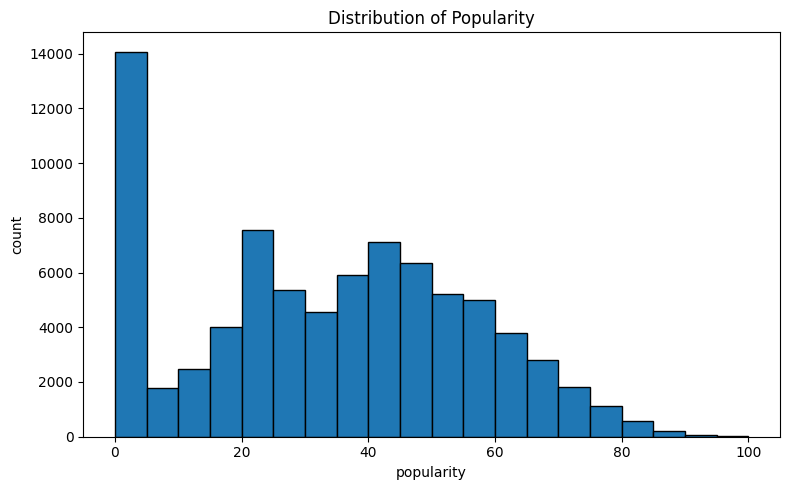

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(train["popularity"], bins=20, edgecolor="black")
plt.xlabel("popularity")
plt.ylabel("count")
plt.title("Distribution of Popularity")
plt.tight_layout()
plt.show()


## 6. 数値特徴量と `popularity` の相関

数値特徴量と目的変数 `popularity` の相関係数を確認する。

相関係数が大きいほど直線的な関係が強い。ただし、相関が小さくても、非線形な関係が存在する可能性はある。


In [ ]:
numeric_columns = train.select_dtypes(include="number").columns

popularity_corr = (
    train[numeric_columns]
    .corr()["popularity"]
    .drop("popularity")
    .sort_values(ascending=False)
)

display(popularity_corr.to_frame("correlation_with_popularity"))


,correlation_with_popularity
loudness,0.050341
danceability,0.039078
time_signature,0.032452
tempo,0.011618
Unnamed: 0,0.000506
energy,-0.001136
liveness,-0.003768
key,-0.005502
duration_ms,-0.007320
mode,-0.012858


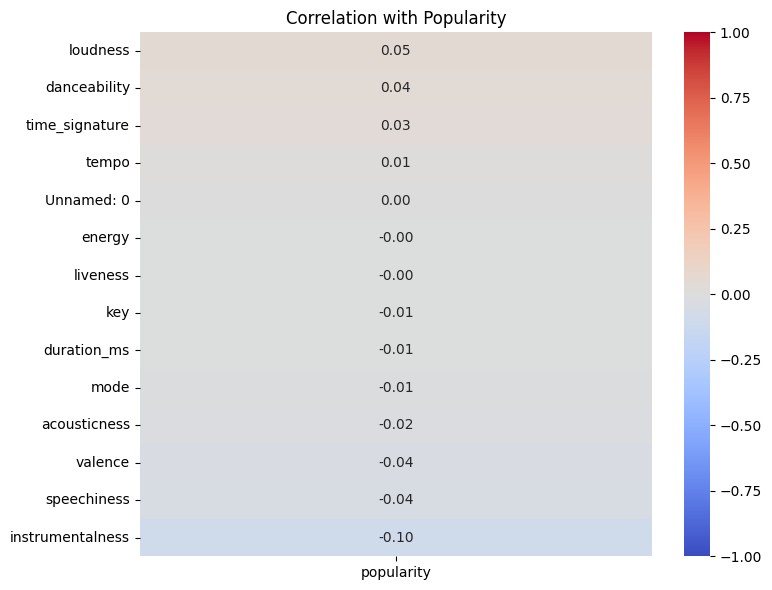

In [ ]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    popularity_corr.to_frame(),
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation with Popularity")
plt.tight_layout()
plt.show()


## 7. 数値特徴量同士の相関ヒートマップ

数値特徴量同士に強い関係があるかを、相関ヒートマップで確認する。

特に、相関係数の絶対値が大きい組み合わせに注目する。


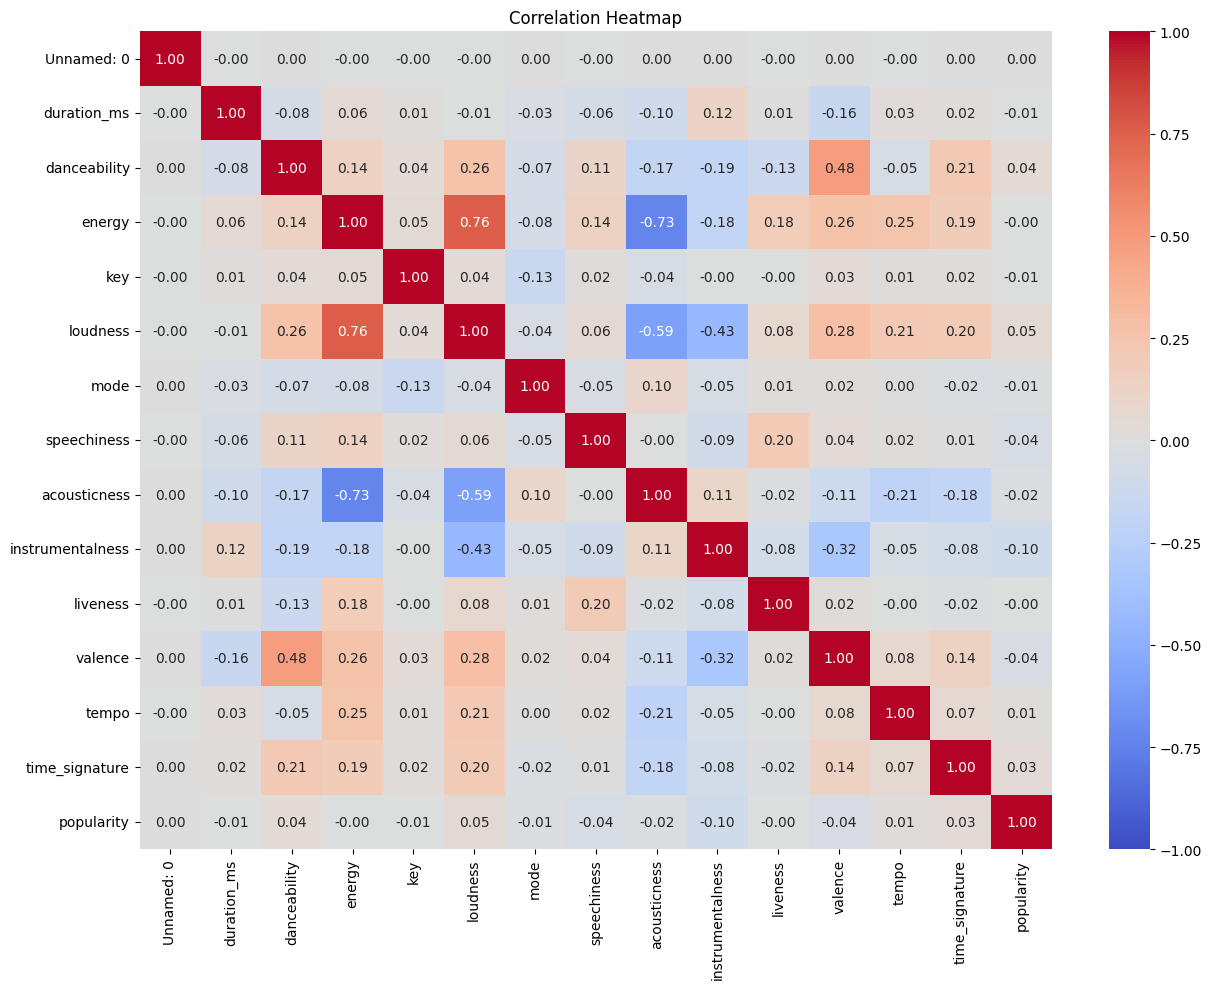

In [ ]:
corr_matrix = train[numeric_columns].corr()

plt.figure(figsize=(13, 10))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


### 相関ヒートマップの注意点

`key`、`mode`、`time_signature` は数値で保存されているが、連続量というよりカテゴリに近い特徴量である。

したがって、これらの相関係数は参考程度に扱う。


## 8. ジャンル別の平均人気度

`track_genre` ごとに、データ数と平均人気度を確認する。


In [ ]:
genre_summary = (
    train.groupby("track_genre")["popularity"]
    .agg(["count", "mean"])
    .sort_values("mean", ascending=False)
)

display(genre_summary.head(20))


,count,mean
track_genre,,
pop-film,712,59.238764
k-pop,716,56.601955
chill,676,53.639053
sad,712,52.882022
indian,715,49.532867
grunge,687,49.165939
anime,697,48.728838
pop,693,48.464646
emo,720,47.734722


## 9. `explicit` 別の平均人気度

成人向け表現の有無によって、平均人気度に差があるかを確認する。


In [ ]:
explicit_summary = (
    train.groupby("explicit")["popularity"]
    .agg(["count", "mean"])
)

display(explicit_summary)


,count,mean
explicit,,
False,72930,32.970218
True,6870,36.473508


## 10. 簡単なまとめ

このNotebookでは、以下を確認した。

- データの規模と列構成
- 欠損値と重複行
- `popularity` の分布
- 数値特徴量と `popularity` の相関
- 数値特徴量同士の相関
- ジャンル別・`explicit` 別の平均人気度

ここで得た結果を参考にして、次の段階では使用する特徴量を決め、回帰モデルを作成する。
